# EDA — ERA5-Land (estado de suelo + heladas)

Features que los **promedios mensuales de clima no capturan**: la condición inicial del
suelo (arrancar seco o inundado) y los eventos puntuales de helada. La hipótesis era que
podrían explicar parte del ~70% de anomalías sin firma climática del techo estructural.
Se probaron en [`experiments/05`](../experiments/05_features_nuevas.ipynb).

**Fuente:** ECMWF/ERA5_LAND/DAILY_AGGR (reanálisis diario ~9 km, 1950+), por departamento
(FAO GAUL nivel 2) vía Google Earth Engine. Cuatro variables por (depto, campaña):

| feature | qué mide |
|---|---|
| `sm_planting` | humedad de suelo 0–100 cm en la siembra (Sep–Nov) |
| `sm_winter` | humedad de suelo en el invierno previo (Jun–Ago) = inercia hídrica |
| `frost_days` | nº de días con helada (Tmin<0 °C) en la campaña (Sep–Mar) |
| `frost_days_early` | heladas tardías de primavera (Sep–Nov), las más dañinas |

Este notebook mira la señal cruda y **destapa el problema de normalización** que fue una
lección de método del proyecto.

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

from src.config import ERA5_COLS, PANEL_ERA5_PATH
from src import data as cdata

panel = cdata.load_panel(PANEL_ERA5_PATH, use_era5=True)
panel = cdata.compute_z_rinde(panel)
print("features ERA5:", ERA5_COLS)
print("campañas:", int(panel.campania_inicio.min()), "→", int(panel.campania_inicio.max()))

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


features ERA5: ['sm_planting', 'sm_winter', 'frost_days', 'frost_days_early']
campañas: 1981 → 2024


## 1 · Cobertura y rangos
ERA5-Land es reanálisis: sin huecos temporales. Humedad de suelo en fracción
volumétrica (0–0.5 ≈ seco a saturado); heladas en número de días.

In [2]:
tab = pd.DataFrame({
    "col": ERA5_COLS,
    "nan_%": [round(panel[c].isna().mean()*100, 1) for c in ERA5_COLS],
    "min": [round(panel[c].min(), 3) for c in ERA5_COLS],
    "mediana": [round(panel[c].median(), 3) for c in ERA5_COLS],
    "max": [round(panel[c].max(), 3) for c in ERA5_COLS],
}).set_index("col")
tab

,nan_%,min,mediana,max
col,,,,
sm_planting,1.0,0.071,0.325,0.534
sm_winter,1.0,0.069,0.337,0.538
frost_days,1.0,0.000,0.000,51.250
frost_days_early,1.0,0.000,0.000,38.118


## 2 · Distribuciones: dos features continuas, dos muy sesgadas
La humedad de suelo se distribuye suave; las heladas están **dominadas por ceros** (la
mayor parte de la región núcleo casi no hiela en primavera-verano). Ese exceso de ceros
es la clave del punto 4.

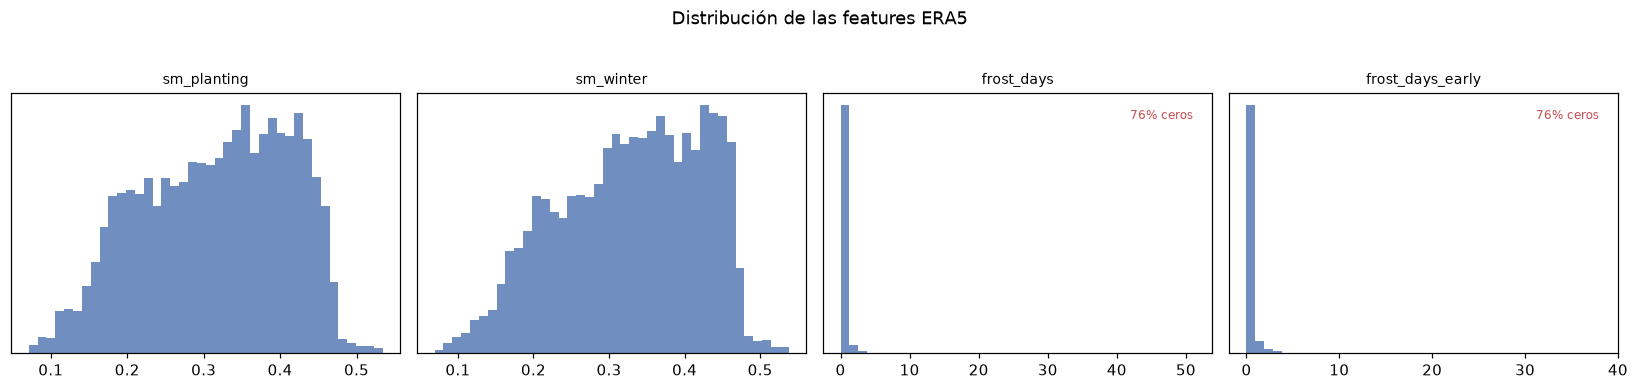

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, c in zip(axes, ERA5_COLS):
    ax.hist(panel[c].dropna(), bins=40, color="#4C72B0", alpha=0.8)
    ax.set_title(c, fontsize=9); ax.set_yticks([])
    ceros = (panel[c] == 0).mean() * 100
    if ceros > 5:
        ax.text(0.95, 0.9, f"{ceros:.0f}% ceros", transform=ax.transAxes,
                ha="right", fontsize=8, color="#C44E52")
fig.suptitle("Distribución de las features ERA5", y=1.03); plt.tight_layout(); plt.show()

## 3 · Humedad de suelo: memoria hídrica
`sm_winter` (invierno previo) debería anticipar `sm_planting` (siembra): un invierno seco
deja el perfil seco para la siembra. Esa correlación es la "inercia" que motivó la
feature.

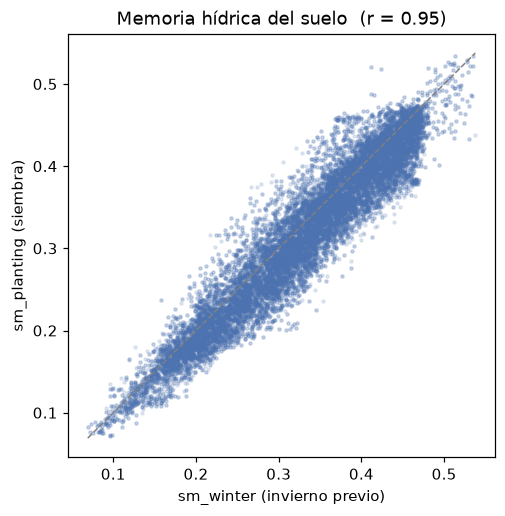

In [4]:
sub = panel[["sm_winter", "sm_planting", "cultivo"]].dropna()
r = sub["sm_winter"].corr(sub["sm_planting"])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sub["sm_winter"], sub["sm_planting"], s=4, alpha=0.15, color="#4C72B0")
lim = [sub[["sm_winter", "sm_planting"]].min().min(), sub[["sm_winter", "sm_planting"]].max().max()]
ax.plot(lim, lim, "--", color="gray", lw=1)
ax.set_xlabel("sm_winter (invierno previo)"); ax.set_ylabel("sm_planting (siembra)")
ax.set_title(f"Memoria hídrica del suelo  (r = {r:.2f})"); plt.show()

## 4 · ⚠️ El problema de las heladas: varianza-cero por departamento
Acá está la lección de método. La normalización del pipeline es **z-score por
departamento**. Pero en el norte de la región **nunca hiela** → `frost_days = 0` en
todas las campañas de esos departamentos → desvío 0 → el z-score da `0/0 = NaN`.

Si esas filas se descartan, el test set se achica y se sesga (se cae toda una región).
Fue exactamente el bug que produjo un "breakthrough" falso de 0.642 antes de corregirlo
con un *fallback a desvío global*. Las heladas se concentran en un subconjunto de
departamentos (por altitud más que por latitud); en la mayoría de la región núcleo son
casi siempre 0.

In [5]:
g = panel.groupby(["provincia", "departamento"])
std0 = g["frost_days"].std().fillna(0)
frac = (std0 == 0).mean()
print(f"departamentos con frost_days de varianza CERO: {(std0==0).sum()}/{len(std0)} "
      f"({frac*100:.0f}%)")
print(f"idem frost_days_early: "
      f"{(g['frost_days_early'].std().fillna(0)==0).mean()*100:.0f}%")
print("\n→ sin el fallback a std global, la normalización tiraría todas esas filas")
print("  (el norte sin heladas) y sesgaría el test. Corregido en _normalize_per_depto.")

departamentos con frost_days de varianza CERO: 116/312 (37%)
idem frost_days_early: 37%

→ sin el fallback a std global, la normalización tiraría todas esas filas
  (el norte sin heladas) y sesgaría el test. Corregido en _normalize_per_depto.


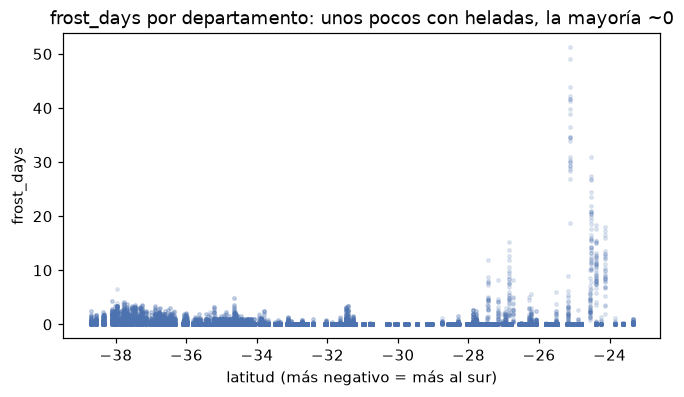

In [6]:
# frost_days por latitud: NO es un gradiente limpio norte-sur (la altitud manda)
if "lat" in panel.columns:
    m = panel.dropna(subset=["lat", "frost_days"])
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.scatter(m["lat"], m["frost_days"], s=5, alpha=0.15, color="#4C72B0")
    ax.set_xlabel("latitud (más negativo = más al sur)"); ax.set_ylabel("frost_days")
    ax.set_title("frost_days por departamento: unos pocos con heladas, la mayoría ~0")
    plt.show()
else:
    print("panel sin columna lat — se omite el mapa por latitud")

## 5 · ¿Separan las anómalas? Suelo seco en siembra
La hipótesis con más sentido agronómico: campañas que **arrancan con el suelo seco**
(`sm_planting` bajo) tendrían más riesgo. Comparación anómalas vs normales (soja).

In [7]:
sub = panel[(panel.cultivo == "soja")].dropna(subset=["anomalia"] + ERA5_COLS)
norm = sub[sub.anomalia == 0]; anom = sub[sub.anomalia == 1]
print(f"normal n={len(norm)}   anómala n={len(anom)}\n")
print("feature            med_normal  med_anómala   Cohen_d")
for c in ERA5_COLS:
    a, n = anom[c], norm[c]
    pooled = np.sqrt((a.var() + n.var()) / 2)
    d = (a.mean() - n.mean()) / pooled if pooled else 0
    print(f"{c:18s} {n.median():9.3f}  {a.median():10.3f}   {d:+.2f}")

normal n=8008   anómala n=1186

feature            med_normal  med_anómala   Cohen_d
sm_planting            0.324       0.299   -0.21
sm_winter              0.335       0.319   -0.19
frost_days             0.000       0.000   -0.02
frost_days_early       0.000       0.000   -0.02


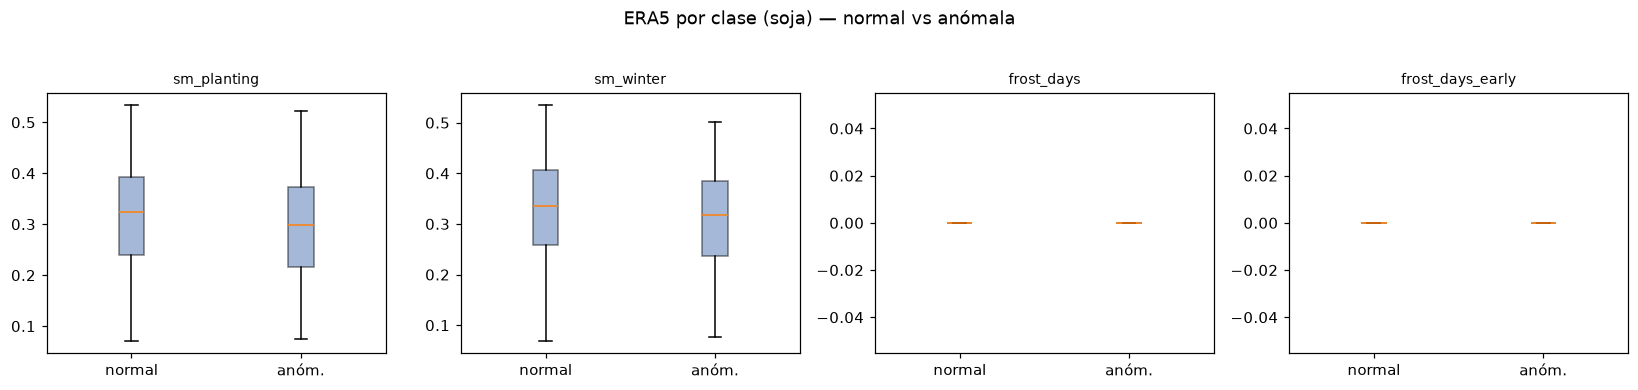

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, c in zip(axes, ERA5_COLS):
    ax.boxplot([norm[c].dropna(), anom[c].dropna()], tick_labels=["normal", "anóm."],
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.5))
    ax.set_title(c, fontsize=9)
fig.suptitle("ERA5 por clase (soja) — normal vs anómala", y=1.03); plt.tight_layout(); plt.show()

## 6 · Conclusión del EDA
- **Datos limpios y coherentes**: humedad de suelo con memoria hídrica real
  (`sm_winter`→`sm_planting`, r≈0.95), heladas concentradas en pocos departamentos.
- **Las heladas son casi todo ceros** en la región núcleo → poca varianza útil, y
  **rompen la normalización por-depto** donde el desvío es 0 (lección de método: el
  fallback a desvío global de `_normalize_per_depto`, sin el cual un test sesgado dio un
  0.642 fantasma).
- **Separación débil** anómala/normal, incluso en `sm_planting` (la de más sentido
  agronómico).

Coherente con [`experiments/05`](../experiments/05_features_nuevas.ipynb): ERA5 ayuda
*modestamente* al IForest (que submuestrea columnas) pero **perjudica al VAE** (diluye el
`recon_prob`), y ninguna combinación supera al modelo base. El estado de suelo y las
heladas no destrapan el techo estructural.